In [21]:
library(readxl)
library(dplyr)
library(Seurat)
library(UCell)
library(stringr)
library(ggplot2)

In [22]:
# 加载小脑 RDS 文件
cerebellum <- readRDS("../cellchat/DN_celltype_res4.rds")

In [23]:
#========================
# 1. 读取基因集
#========================
read_geneset <- function(file){
  x <- readLines(file, warn = FALSE)
  x <- trimws(x)
  x <- x[x != ""]
  unique(x)
}

geneSets_list <- list(
  common_gene_LSBL_Z4   = read_geneset("common_gene_LSBL_Z4.txt"),
  combine60_LSBL_Z4     = read_geneset("combine60_LSBL_Z4.txt"),
  parlor_roller_LSBL_Z4 = read_geneset("parlor_roller_LSBL_Z4.txt"),
  Xinjiang_LSBL_Z4      = read_geneset("Xinjiang_LSBL_Z4.txt")
)

#========================
# 2. 鸽子数据适配处理
#========================
data_genes <- rownames(cerebellum)

geneSets_cleaned <- lapply(geneSets_list, function(gs) {
  gs <- unique(trimws(gs))
  gs <- gs[gs != ""]
  
  gs_upper <- toupper(gs)
  data_genes_upper <- toupper(data_genes)
  
  # 找到在表达矩阵中存在的基因（大小写不敏感）
  valid_upper <- intersect(gs_upper, data_genes_upper)
  
  # 返回表达矩阵中的原始格式基因名
  data_genes[data_genes_upper %in% valid_upper]
})

#========================
# 3. 打印匹配统计
#========================
match_stats <- data.frame(
  signature = names(geneSets_list),
  input_n   = sapply(geneSets_list, length),
  matched_n = sapply(geneSets_cleaned, length),
  match_rate = round(sapply(geneSets_cleaned, length) / sapply(geneSets_list, length), 3)
)

cat("基因集匹配统计：\n")
print(match_stats)

基因集匹配统计：
                                  signature input_n matched_n match_rate
common_gene_LSBL_Z4     common_gene_LSBL_Z4      10         7      0.700
combine60_LSBL_Z4         combine60_LSBL_Z4     166       131      0.789
parlor_roller_LSBL_Z4 parlor_roller_LSBL_Z4      93        68      0.731
Xinjiang_LSBL_Z4           Xinjiang_LSBL_Z4     170       125      0.735


In [24]:
# 3. 运行 UCell 打分
# ------------------------------------------------------------------------------
# UCell 直接集成在 Seurat 工作流中，不需要手动转换矩阵
# ncores 可以根据你的服务器配置调整

message("Running UCell scoring...")
cerebellum <- AddModuleScore_UCell(
  obj = cerebellum,
  features = geneSets_cleaned,
  ncores = 1,                 # 如果环境依然敏感，设为1；否则可设为4或8加速
  name = "_UCell"             # 结果列名会以 _UCell 结尾
)

# 查看打分后的 MetaData 列名
# 结果通常命名为：OXPHOS_UCell, Metabolism_UCell 等
head(cerebellum@meta.data)

Running UCell scoring...



,orig.ident,nCount_RNA,nFeature_RNA,individual.id,percent.mt,percent.ribo,group,RNA_snn_res.0.01,RNA_snn_res.0.05,RNA_snn_res.0.1,⋯,RNA_snn_res.7,RNA_snn_res.8,RNA_snn_res.9,RNA_snn_res.10,seurat_clusters,cell_type,common_gene_LSBL_Z4_UCell,combine60_LSBL_Z4_UCell,parlor_roller_LSBL_Z4_UCell,Xinjiang_LSBL_Z4_UCell
,<fct>,<dbl>,<int>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
WMS420-DN_AACAACACGAAATCCATTCT,WMS420-DN,1388,941,WMS420,0.7204611,0.00000000,homing,2,2,2,⋯,21,18,13,16,33,astrocytes,0.2702857,0.1082697,0.1133627,0.1585947
WMS420-DN_AACAACACGAGACCACTATT,WMS420-DN,8125,2879,WMS420,0.4307692,0.08615385,homing,0,1,1,⋯,48,44,68,63,16,excitatory neurons,0.2469524,0.1618270,0.1389853,0.1726453
WMS420-DN_AACAACACGAGCCGCAAGCG,WMS420-DN,11143,3157,WMS420,0.2333303,0.02692273,homing,1,9,11,⋯,9,10,115,4,13,inhibitory neurons,0.2690000,0.1885725,0.1495784,0.1688107
WMS420-DN_AACAACACGAGCGTAACGTC,WMS420-DN,2779,1484,WMS420,0.4677942,0.07196833,homing,0,1,1,⋯,35,29,29,28,12,excitatory neurons,0.0527619,0.1299237,0.1158235,0.1430587
WMS420-DN_AACAAGTGATACGCAGCGAA,WMS420-DN,5648,2031,WMS420,0.2124646,0.10623229,homing,0,10,12,⋯,93,100,109,27,18,excitatory progenitors,0.2535238,0.1406361,0.1201373,0.1349813
WMS420-DN_AACAAGTGATAGGTTGGCAG,WMS420-DN,2736,1445,WMS420,2.3391813,0.25584795,homing,3,4,3,⋯,38,77,82,84,19,oligodendrocytes,0.1104762,0.1343588,0.1048186,0.1339227


In [25]:
unique(cerebellum@meta.data$cell_type)

[1] astrocytes                     excitatory neurons            
 [3] inhibitory neurons             excitatory progenitors        
 [5] oligodendrocytes               endothelial                   
 [7] vasculature-associated cells   microglia                     
 [9] red blood cells                Oligodendrocyte precursor cell
[11] inhibitory progenitors        
11 Levels: Oligodendrocyte precursor cell astrocytes ... vasculature-associated cells

In [26]:
library(ggpubr)
library(rstatix) # 方便进行批量校正

pathways <- c("common_gene_LSBL_Z4_UCell",
  "combine60_LSBL_Z4_UCell",
  "parlor_roller_LSBL_Z4_UCell",
  "Xinjiang_LSBL_Z4_UCell")

for(pw in pathways){
  if(!pw %in% colnames(cerebellum@meta.data)) next

  # 1. 提取数据
  plot_data <- FetchData(cerebellum, vars = c(pw, "cell_type", "group"))
  plot_data$cell_type <- trimws(plot_data$cell_type) # 清理空格

  p <- ggplot(plot_data, aes(x = cell_type, y = .data[[pw]], fill = group)) +
       # 1. 基础小提琴图和箱线图 (保持不变)
       geom_violin(scale = "width", adjust = 1, trim = TRUE, 
                   position = position_dodge(width = 0.9), alpha = 0.8) +
       geom_boxplot(width = 0.1, color = "black", outlier.shape = NA, 
                    position = position_dodge(width = 0.9)) +
       
       # =============================================================
       # 核心修改点：添加统计检验标记
       # method = "wilcox.test" (对应你的 Wilcoxon Test)
       # label = "p.signif" (显示 ns, *, **, ***)
       # =============================================================
       stat_compare_means(
         aes(group = group), 
         method = "wilcox.test", 
         label = "p.signif", 
         label.y = max(plot_data[[pw]]) + 0.02, # 自动调整标签高度
         hide.ns = FALSE                       # 是否隐藏 'ns' (建议显示)
       ) +
       
       # 2. 主题和样式 (保持不变，或微调颜色)
       theme_bw() +
       theme(
         axis.text.x = element_text(angle = 45, hjust = 1),
         panel.grid.major = element_blank(),
         panel.grid.minor = element_blank()
       ) +
       scale_fill_manual(values = c("homing" = "#4DBBD5FF", "tumbler" = "#E64B35FF")) +
       labs(title = paste("Pathway Analysis:", pw), 
            subtitle = "Statistics: Wilcoxon Test (ggpubr automatic)",
            y = "UCell Score", x = "Cell Cluster")

  # 4. 导出
  filename <- paste0("Comparison_with_Padj_", pw, ".pdf")
  ggsave(filename, plot = p, width = 14, height = 7, dpi = 300)
}

In [27]:
library(tidyverse)

# 1. 初始化列表存储结果
summary_stats <- list()

message("正在量化各细胞类型的差异程度...")

for(pw in pathways){
  if(!pw %in% colnames(cerebellum@meta.data)) next
  
  # 提取当前通路数据
  data_tmp <- FetchData(cerebellum, vars = c(pw, "cell_type", "group"))
  data_tmp$cell_type <- trimws(data_tmp$cell_type)
  
  # 计算每个 cluster 的统计量
  res <- data_tmp %>%
    group_by(cell_type) %>%
    # 确保两组都有细胞，否则无法比较
    filter(n_distinct(group) == 2) %>% 
    summarise(
      Pathway = pw,
      # 计算均值
      Mean_Homing = mean(.data[[pw]][group == "homing"]),
      Mean_Tumbler = mean(.data[[pw]][group == "tumbler"]),
      # 计算 Log2 Fold Change (Tumbler / Homing)
      Log2FC = log2(Mean_Tumbler / Mean_Homing),
      # 计算 Wilcoxon P值
      P_Val = wilcox.test(.data[[pw]] ~ group)$p.value,
      .groups = 'drop'
    )
  
  summary_stats[[pw]] <- res
}

# 2. 合并并计算校正后的 P 值 (FDR/BH)
df_plot <- bind_rows(summary_stats) %>%
  mutate(Padj = p.adjust(P_Val, method = "BH")) %>%
  mutate(neg_logP = -log10(Padj + 1e-10)) # 用于绘图点的大小

# 保存统计结果到 Excel
# openxlsx::write.xlsx(df_plot, "Pathway_Difference_Quantification.xlsx")

正在量化各细胞类型的差异程度...



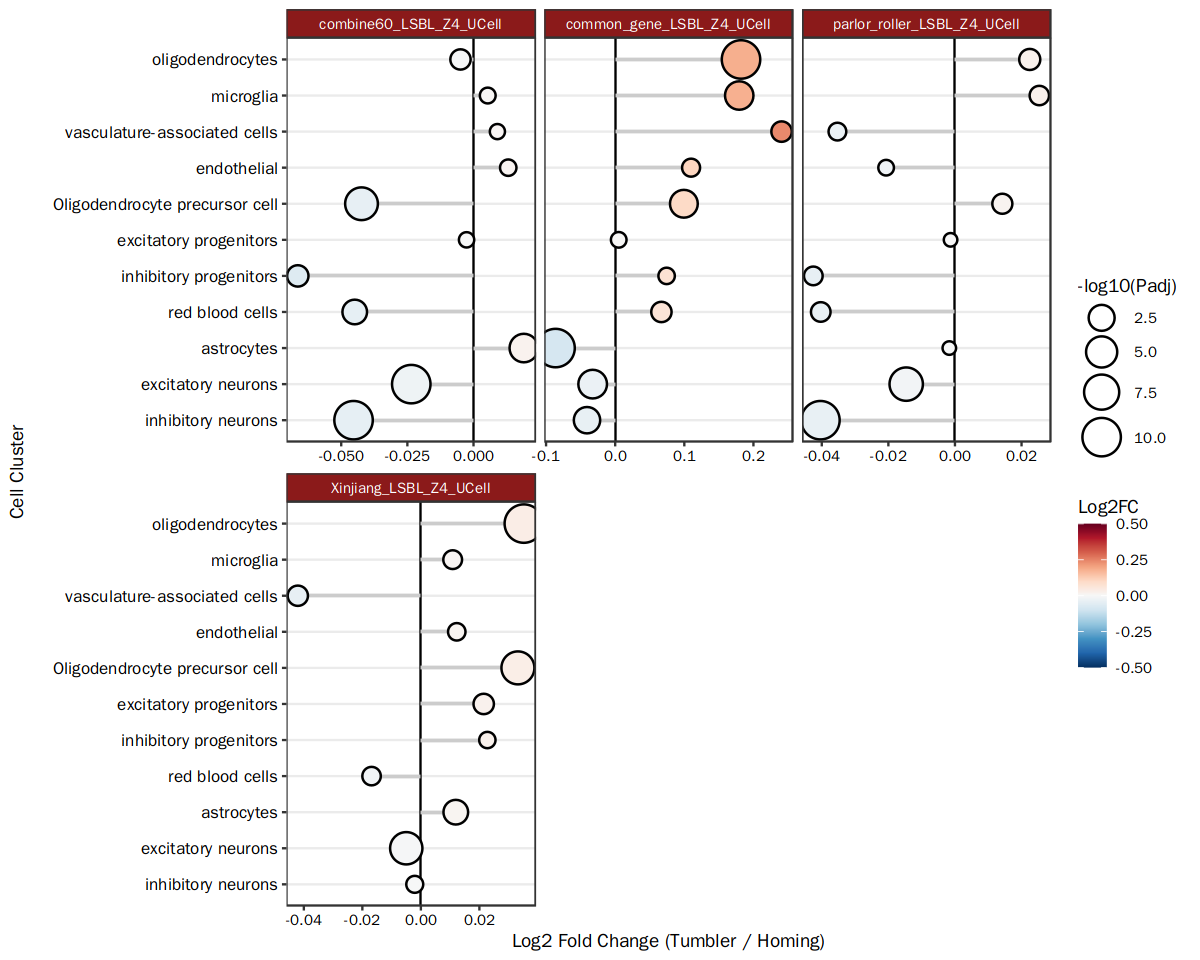

In [28]:
# 重新定义绘图对象，重点修改颜色部分
p_quant_v2 <- ggplot(df_plot, aes(x = Log2FC, y = reorder(cell_type, Log2FC))) +
  geom_vline(xintercept = 0, linetype = "solid", color = "black", size = 0.5) +
  geom_segment(aes(yend = cell_type, xend = 0), color = "grey80", size = 0.8) +
  
  # 增加 stroke 让黑边更明显，提高立体感
  geom_point(aes(size = neg_logP, fill = Log2FC), shape = 21, color = "black", stroke = 0.8) +
  
  # 关键修改：oob = scales::squish 会把超出范围的颜色强制显示为最深色
  # 这样可以让 0.2 这种小差异也显示出明显的颜色
  scale_fill_gradientn(
    colors = rev(RColorBrewer::brewer.pal(11, "RdBu")), 
    limits = c(-0.5, 0.5), # 强制将颜色范围限制在 -0.5 到 0.5，超出部分显示最深红/深蓝
    oob = scales::squish,
    name = "Log2FC"
  ) +
  
  scale_size_continuous(range = c(3, 10), name = "-log10(Padj)") +
  
  facet_wrap(~Pathway, scales = "free_x", ncol = 3) +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 10, color = "black", face = "bold"),
    axis.text.x = element_text(color = "black"),
    strip.background = element_rect(fill = "firebrick4"), # 换成深红色标题框
    strip.text = element_text(color = "white", face = "bold"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  labs(x = "Log2 Fold Change (Tumbler / Homing)", y = "Cell Cluster")

print(p_quant_v2)

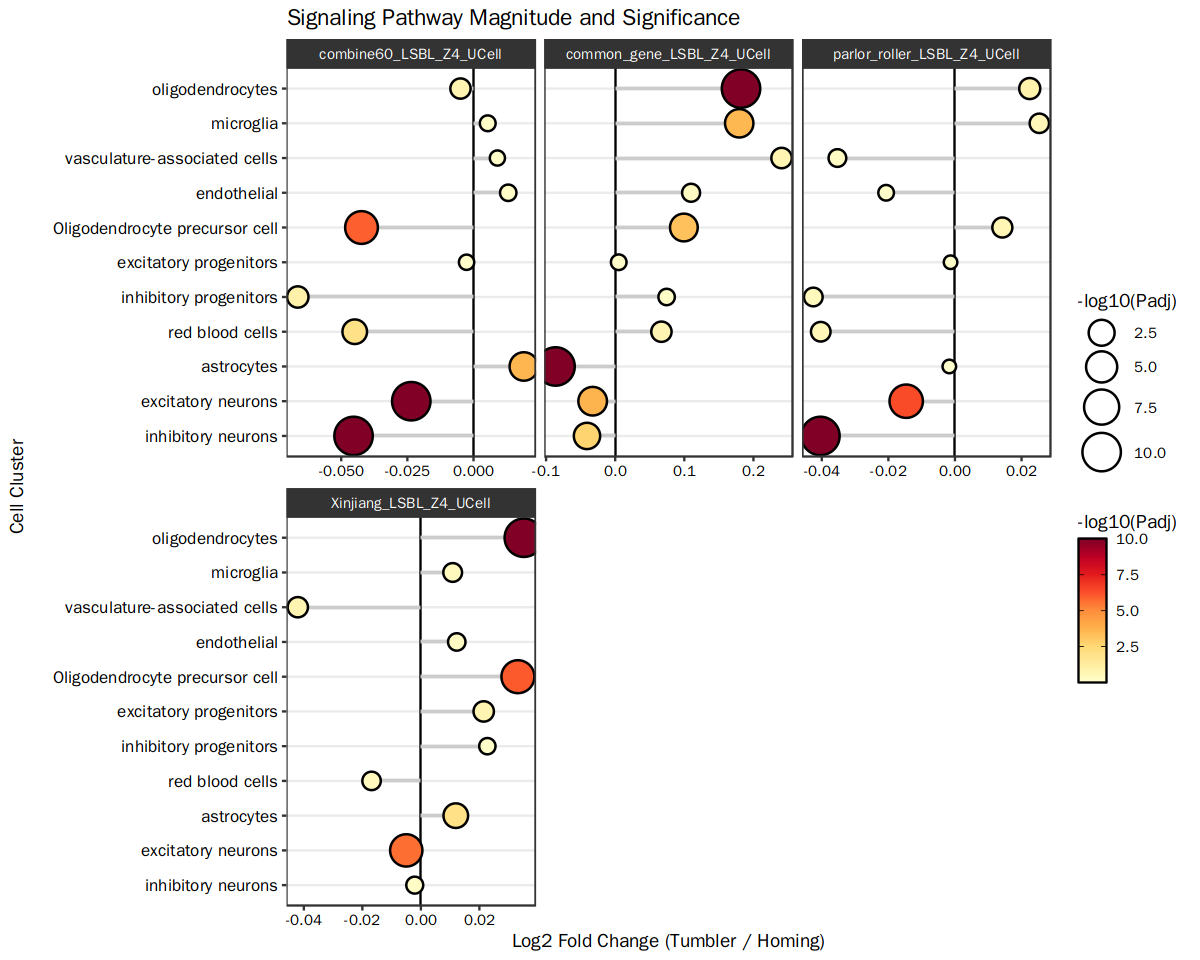

In [29]:
# 重新定义绘图对象：颜色映射改为显著性 (-log10 Padj)
p_quant_v3 <- ggplot(df_plot, aes(x = Log2FC, y = reorder(cell_type, Log2FC))) +
  geom_vline(xintercept = 0, linetype = "solid", color = "black", size = 0.5) +
  geom_segment(aes(yend = cell_type, xend = 0), color = "grey80", size = 0.8) +
  
  # 颜色映射改为 neg_logP，点的大小可以继续保留显著性，或者改为别的度量
  geom_point(aes(size = neg_logP, fill = neg_logP), shape = 21, color = "black", stroke = 0.8) +
  
  # 颜色比例尺修改：使用单色渐变，越红代表越显著
  scale_fill_gradientn(
    colors = RColorBrewer::brewer.pal(9, "YlOrRd"), 
    name = "-log10(Padj)",
    guide = guide_colorbar(frame.colour = "black", ticks.colour = "black")
  ) +
  
  scale_size_continuous(range = c(3, 10), name = "-log10(Padj)") +
  
  facet_wrap(~Pathway, scales = "free_x", ncol = 3) +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 10, color = "black", face = "bold"),
    axis.text.x = element_text(color = "black"),
    # 标题框颜色可以根据文章风格调整，这里保留深红色或改为深蓝色
    strip.background = element_rect(fill = "grey20"), 
    strip.text = element_text(color = "white", face = "bold"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  ) +
  labs(
    x = "Log2 Fold Change (Tumbler / Homing)", 
    y = "Cell Cluster",
    title = "Signaling Pathway Magnitude and Significance"
  )

print(p_quant_v3)

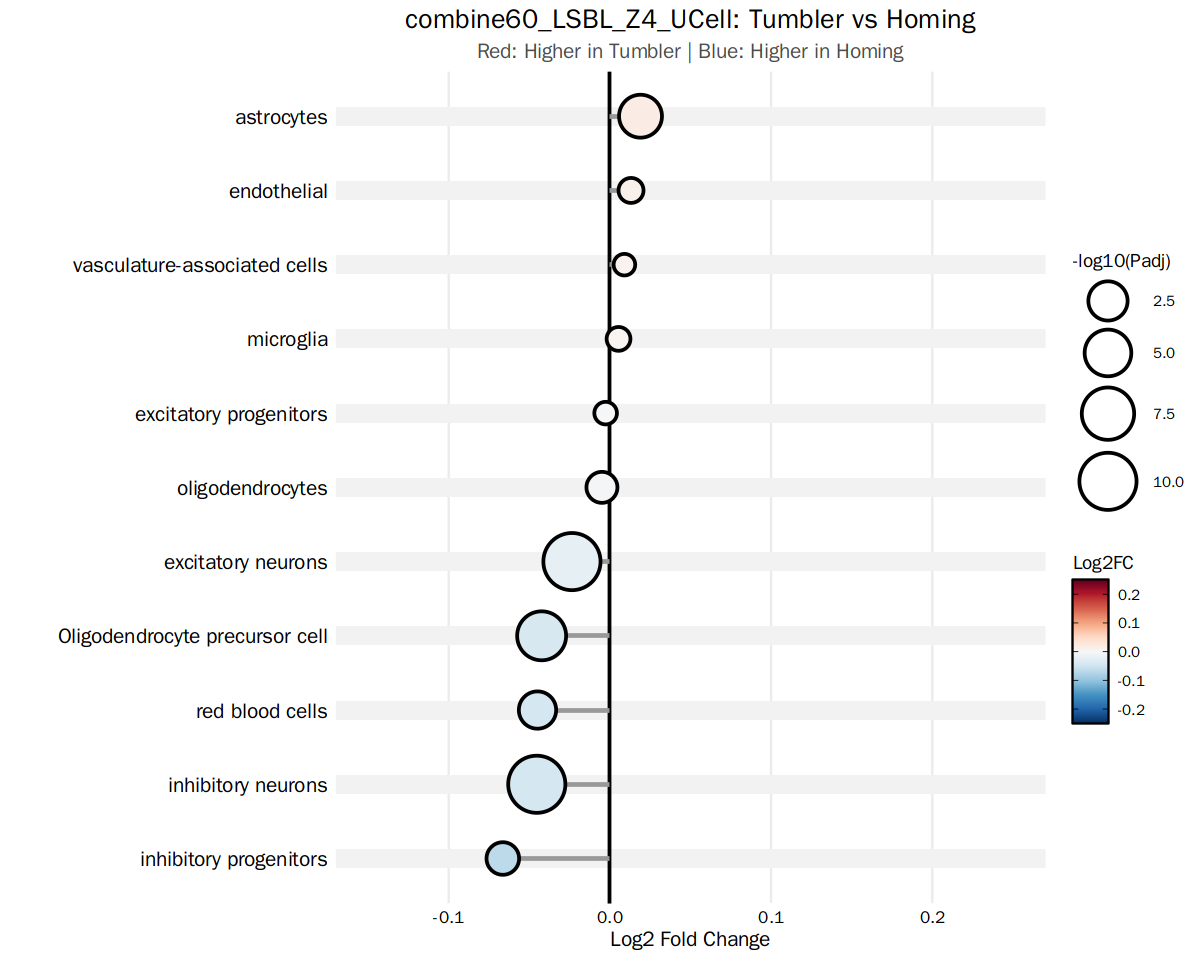

In [33]:
options(repr.plot.width = 10, repr.plot.height = 8)
library(ggplot2)
library(scales)
library(RColorBrewer)

# 1. 筛选 OXPHOS 数据并清理
df_oxphos <- df_plot %>% 
  filter(Pathway == "combine60_LSBL_Z4_UCell") %>%
  mutate(cell_type = trimws(cell_type))

# 2. 绘制高对比度棒棒糖图
p_oxphos <- ggplot(df_oxphos, aes(x = Log2FC, y = reorder(cell_type, Log2FC))) +
  # 添加背景带，交替颜色增加可读性
  geom_hline(yintercept = seq_along(unique(df_oxphos$cell_type)), color = "grey95", size = 4) +
  # 强化中心零线
  geom_vline(xintercept = 0, linetype = "solid", color = "black", size = 0.8) +
  # 强化连接线
  geom_segment(aes(yend = cell_type, xend = 0), color = "grey60", size = 1) +
  
  # 绘制气泡：shape=21带边框，stroke增加边框厚度
  geom_point(aes(size = neg_logP, fill = Log2FC), shape = 21, color = "black", stroke = 1.2) +
  
  # 颜色映射：极限压缩到 -0.2 到 0.2
  # 这样微小的生物学差异在视觉上也会非常震撼
  scale_fill_gradientn(
    colors = rev(brewer.pal(11, "RdBu")), 
    limits = c(-0.25, 0.25), 
    oob = squish,
    guide = guide_colorbar(frame.colour = "black", ticks.colour = "black", barwidth = 1.5)
  ) +
  
  # 放大气泡尺寸范围
  scale_size_continuous(range = c(5, 15), name = "-log10(Padj)") +

  scale_x_continuous(limits = c(-0.15, 0.25))+
  
  theme_minimal() + # 使用极简主题突出数据
  labs(
    title = "combine60_LSBL_Z4_UCell: Tumbler vs Homing",
    subtitle = "Red: Higher in Tumbler | Blue: Higher in Homing",
    x = "Log2 Fold Change",
    y = ""
  ) +
  theme(
    # 显著加粗加黑纵轴文字
    axis.text.y = element_text(size = 12, color = "black", face = "bold"),
    axis.text.x = element_text(size = 10, color = "black", face = "bold"),
    axis.title.x = element_text(size = 12, face = "bold"),
    # 移除多余网格线
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5, color = "grey30"),
    legend.position = "right",
    legend.title = element_text(face = "bold")
  )

# 打印查看
print(p_oxphos)

outfile_pdf <- file.path(getwd(), "plots", "combine60LSBLZ4_lollipop.pdf")
outfile_png <- file.path(getwd(), "plots", "combine60LSBLZ4_lollipop.png")

ggsave(outfile_pdf, plot = p_oxphos, device = "pdf", width = 10, height = 8, units = "in")
ggsave(outfile_png, plot = p_oxphos, width = 10, height = 8, dpi = 300, units = "in")